If you have run the previous notebook ```01_simulate_data.ipynb```, you would have generated two types of data: "ambiguous" and the "ground-truth". 
- Ground-Truth: When we employ simulated data for our analysis, we generate the data using an ML-MAR model. The time-series we obtain from the model is our ground-truth or reference data.
- Ambiguous Data: To ambiguate this ground-truth data, we randomly flip (/change signs of) some channels for each subject file. This is the data on which we apply the sign flipping algorithm.
Having the ground-truth in this situation allows us to have something to compare our solution to (since we already know which channels we ambiguously flipped).

In this notebook, we take the simulated data (or any other data that you want to apply the sign-flipping solution on) and load it in a way that the functions can use it later on for analysis. This can be done in three steps:
1. Load ambiguous data
2. Load ground-truth data (if you have any)
3. Call the sign-flipping functions

### 1. Loading Ambiguous Data
Important points to note:
- The data needs to arranged in a single folder for all subjects.
- These could be .mat files or .npy files.
- All the subject data files need to have the same number of channels.

#### 1a. Loading .mat files
The next couple of steps help you load data if your data is formatted as matlab files ```.mat```

In [ ]:
from pathlib import Path

In [2]:
# loading data in the appropriate form
directory = 'simulated_data' # specify the folder where all subject files are located
format = 'matlab' # specify whether they are "matlab" files or "numpy"

If you navigate to the data folder provided,  you will see that there are two different types of files present:
1. Ambiguous Data files - these are the ones containing data that needs to be 'fixed' in a manner of speaking. These files are named as ```subject**_ambiguous_data.mat'```
2. Ground-truth or Reference Data files - essentially these are the ones that we 'wrongly flipped' to obtain the ambiguous data. These files are named as ```unflipped_data_subject_**.mat'```

Now it may very well be the case, that you only have the ambiguous data that you need to correctly 'flip'. Or you may have simulated data in the previous step using the ML-MAR model and you do, in fact have both the ambiguous data and the ground-truth data. 

For either case, there is a cell that you can run from the following two cells:

In [3]:
# if all files in your directory have a single naming convention or if you do not have reference data available,
# you can simply run this cell to get all the files in your directory
directory_in_str = Path(directory)
matfiles = list(directory_in_str.iterdir())

In [4]:
# however if you have reference data available and it is named using a different convention as your "ambiguous" data
# you should run this cell instead and specify the naming convention to identify your "ambiguous" files

convention = '**/*ambiguous*.mat';  # specify how to identify the ambiguous files in your data
directory_in_str = Path(directory)

# sepcify how to sort your files in ascending order
matfiles = sorted(Path(directory_in_str).glob(convention), key=lambda path: int(path.stem.rsplit("subject_", 1)[1]))

In [5]:
# print files to have a look
# matfiles

Now that we have gathered together our necessary files, we can combine them together in a way that the dipole-flip scripts can read them.
For this we would need to specify the way in which the data is saved in the .mat files. As you can see in the data provided, once you load the .mat file, there is a single struct 'S' located which further has multiple fields and variables. Of these, there are two of interest to us: "nsamples" and "data". We will try in the following cells to obtain these two variables, however they may be arranged in your data.
<div>
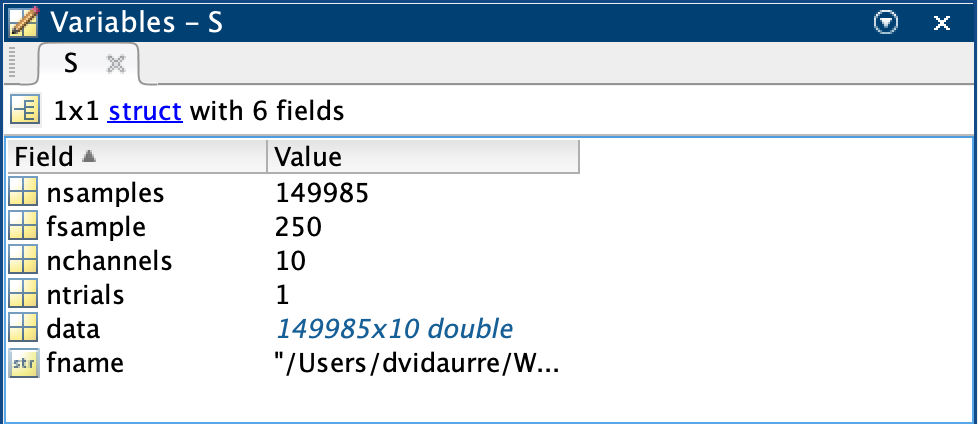
<div>

In [6]:
data_variable = 'data' # specify the name of the variable where your data is located
T_variable = 'nsamples' # specify the name of the variable which holds how many number of data samples a subject file has
subjects = 10  # specify the number of subjects in your data

An important thing to note is that the data for a single subject needs to be arranged in the form ```[no. of data points x no. of channels]```. So, we might need to take transpose to do this properly.

In [7]:
transp = False  # specify whether your data array needs to be transposed or not

In [8]:
import numpy as np 
import scipy
import pandas as pd

sub_no = 0
amb_dict = {}  # the dict of Dataframe that holds all the patient data
T_array = np.empty(subjects)  # the array that holds the no of sample points for each subject

for matfile in matfiles:
    path_in_str = str(matfile)
    mat = scipy.io.loadmat(path_in_str)

    data = mat[data_variable]  # the struct in the .mat file that holds all data
    T_ = mat[T_variable]

    # * get data from the struct and arrange in dataframe
    if transp is True:
        df = pd.DataFrame(data.T)
    else:
        df = pd.DataFrame(data)

    # * save this dataframe with the other subjects'
    amb_dict[sub_no] = df
    T_array[sub_no] = T_
    sub_no = sub_no + 1

/var/folders/vf/vbsp_5fx5xv9ymt2h_gt47d40000gn/T/ipykernel_9977/2098335620.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  T_array[sub_no] = T_


In [9]:
amb_dict[3]

,0,1,2,3,4,5,6,7,8,9
0,43.752268,-17.611267,-24.251940,20.456867,-18.279428,48.987985,-18.671737,-0.161882,14.178126,5.088920
1,35.395043,-18.104504,-18.068534,21.857700,-22.629752,58.762280,-17.168531,-3.850451,12.714598,-1.286510
2,13.495243,-16.524334,-12.089917,15.830428,-13.068785,46.578343,-7.511162,-2.856604,1.635732,-5.419012
3,-17.615578,-8.769879,-5.542918,0.461064,7.990738,14.478760,8.437903,7.172541,-14.774808,-5.529662
4,-46.261645,1.342323,6.324905,-18.471917,24.635753,-18.157811,23.400244,22.527611,-25.535468,-3.941240
...,...,...,...,...,...,...,...,...,...,...
149980,-23.726761,0.060292,18.874302,-25.720076,25.521048,-6.776736,37.302306,-20.554298,-9.307860,2.994523
149981,-14.674004,-6.635461,16.169060,-9.424321,13.764389,-13.852513,32.365315,1.862720,8.902419,1.394463
149982,6.038758,-12.320151,14.156687,6.472484,-1.433791,-12.912610,19.788403,15.984519,29.745534,-5.789899
149983,21.774487,-10.666748,9.074025,13.191391,-14.288286,-3.448615,7.643710,16.613823,42.929814,-13.173365


#### 1b. Loading .npy files
The following steps will help you load files if they are numpy files ```.npy```

---In Progress---

### 2. Loading Reference or Ground-Truth Data
Important points to note:
- The data needs to arranged in a single folder for all subjects.
- These could be .mat files or .npy files.
- All the subject data files need to have the same number of channels.

#### 2a. Loading .mat files
The following steps will help you load files if they are matlab files ```.mat```.

Most of the steps are the same as above. The only difference is in the naming convention of these files.

In [10]:
# loading data in the appropriate form
directory = 'simulated_data' # specify the folder where all subject files are located
format = 'matlab' # specify whether they are "matlab" files or "numpy"

convention = '**/*unflipped*.mat'  # specify how to identify the reference files in your data

directory_in_str = Path(directory)
matfiles = sorted(Path(directory_in_str).glob(convention), key=lambda path: int(path.stem.rsplit("subject_", 1)[1]))

In [11]:
data_variable = 'data' # specify the name of the variable where your data is located
T_variable = 'nsamples' # specify the name of the variable which holds how many number of data samples a subject file has
subjects = 10  # specify the number of subjects in your data

In [12]:
transp = False  # specify whether your data array needs to be transposed or not

In [13]:
# matfiles

In [14]:
import numpy as np 

sub_no = 0  # best to start the numbering of subjects from 0
ref_dict = {}  # the dict of Dataframe that holds all the patient data - ground truth
T_ref = np.empty(subjects)  # the array that holds the no of sample points for each subject

for matfile in matfiles:
    path_in_str = str(matfile)
    mat = scipy.io.loadmat(path_in_str)

    data = mat[data_variable]  # the struct in the .mat file that holds all data
    T_ = mat[T_variable]

    # * get data from the struct and arrange in dataframe
    if transp is True:
        df = pd.DataFrame(data.T)
    else:
        df = pd.DataFrame(data)

    # * save this dataframe with the other subjects'
    ref_dict[sub_no] = df
    T_ref[sub_no] = T_
    sub_no = sub_no + 1

/var/folders/vf/vbsp_5fx5xv9ymt2h_gt47d40000gn/T/ipykernel_9977/2843127213.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  T_ref[sub_no] = T_


In [15]:
ref_dict[3]

,0,1,2,3,4,5,6,7,8,9
0,43.752268,-17.611267,24.251940,-20.456867,18.279428,48.987985,18.671737,-0.161882,14.178126,5.088920
1,35.395043,-18.104504,18.068534,-21.857700,22.629752,58.762280,17.168531,-3.850451,12.714598,-1.286510
2,13.495243,-16.524334,12.089917,-15.830428,13.068785,46.578343,7.511162,-2.856604,1.635732,-5.419012
3,-17.615578,-8.769879,5.542918,-0.461064,-7.990738,14.478760,-8.437903,7.172541,-14.774808,-5.529662
4,-46.261645,1.342323,-6.324905,18.471917,-24.635753,-18.157811,-23.400244,22.527611,-25.535468,-3.941240
...,...,...,...,...,...,...,...,...,...,...
149980,-23.726761,0.060292,-18.874302,25.720076,-25.521048,-6.776736,-37.302306,-20.554298,-9.307860,2.994523
149981,-14.674004,-6.635461,-16.169060,9.424321,-13.764389,-13.852513,-32.365315,1.862720,8.902419,1.394463
149982,6.038758,-12.320151,-14.156687,-6.472484,1.433791,-12.912610,-19.788403,15.984519,29.745534,-5.789899
149983,21.774487,-10.666748,-9.074025,-13.191391,14.288286,-3.448615,-7.643710,16.613823,42.929814,-13.173365


### 3. Run Dipole-Flipping Algorithm

Now that we have organised our data the way it can be used by the following functions, we can actually run these functions.


In [16]:
from find_and_flip import compute_ref_flips

ref_data_available = True  # specify if you have the ground-truth data available
low_power_solution = False  # specify whether you want a quick solution involving creation of hierarchical levels

# we compute here a matrix that compares the ground-truth to the ambiguous data and shows which channels have been flipped
if (ref_data_available is True):
    flips_ref = compute_ref_flips(amb_dict, ref_dict)
else:
    flips_ref = []

In [17]:
flips_ref

array([[1., 0., 0., 0., 1., 1., 1., 1., 0., 0.],
       [0., 0., 1., 0., 1., 1., 1., 1., 1., 1.],
       [0., 1., 1., 0., 1., 1., 1., 0., 0., 1.],
       [0., 0., 1., 1., 1., 0., 1., 0., 0., 0.],
       [1., 0., 0., 1., 0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 1., 1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1., 1., 1., 1., 1., 0.],
       [1., 0., 1., 0., 1., 0., 0., 0., 1., 0.],
       [1., 0., 1., 1., 0., 1., 1., 1., 1., 0.],
       [0., 0., 1., 0., 0., 0., 1., 0., 1., 1.]])

In [18]:
# specify options here to run the algorithm
options = {
        "max_cyc": 1000,
        "standardize": 1
    }

In [19]:
# compute flips

# if you want to run the low-power hierarchical solution, you would have to specify an arrangement "subject_arr" using which a hierarchy is created (see hierarchical_solution.py)
# additionally you would have to call the function "quick_flip" instead of "compute_flip"

from hierarchical_solution import quick_flip
from find_flip import compute_flip

if low_power_solution is True:
    options = {"hierarchical_sol": 1,
               "max_cyc": 1000,
                "standardize": 1}
    subject_arr = [5,1]  # * the arrangement to group subjects # todo fix
    flips = quick_flip(data = amb_dict, T=T_array, options=options, subject_arrangement=subject_arr)

else:
    flips = compute_flip(data=amb_dict, flips_ref=flips_ref, T=T_array, options=options)

Run 0 Initial Score -0.006638682652041352 Initial Accuracy 0.48246913580246914
Run 0 Cycle 0 Score -0.0014994408691592679 Accuracy 0.48592592592592593 Flipped channel: [4] Flipped subject: [7]
Run 0 Cycle 1 Score 0.004057443337396361 Accuracy 0.494320987654321 Flipped channel: [5] Flipped subject: [4]
Run 0 Cycle 2 Score 0.0112133166217918 Accuracy 0.49777777777777776 Flipped channel: [5] Flipped subject: [3]
Run 0 Cycle 3 Score 0.019358655184212054 Accuracy 0.5022222222222222 Flipped channel: [4] Flipped subject: [8]
Run 0 Cycle 4 Score 0.02539512982194489 Accuracy 0.5135802469135803 Flipped channel: [6] Flipped subject: [5]
Run 0 Cycle 5 Score 0.03078327747826465 Accuracy 0.5219753086419753 Flipped channel: [0] Flipped subject: [8]
Run 0 Cycle 6 Score 0.036077843816026675 Accuracy 0.5313580246913581 Flipped channel: [0] Flipped subject: [0]
Run 0 Cycle 7 Score 0.040005093813190715 Accuracy 0.5377777777777778 Flipped channel: [8] Flipped subject: [3]
Run 0 Cycle 8 Score 0.046160788621

In [25]:
flips_ref

array([[1., 0., 0., 0., 1., 1., 1., 1., 0., 0.],
       [0., 0., 1., 0., 1., 1., 1., 1., 1., 1.],
       [0., 1., 1., 0., 1., 1., 1., 0., 0., 1.],
       [0., 0., 1., 1., 1., 0., 1., 0., 0., 0.],
       [1., 0., 0., 1., 0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 1., 1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1., 1., 1., 1., 1., 0.],
       [1., 0., 1., 0., 1., 0., 0., 0., 1., 0.],
       [1., 0., 1., 1., 0., 1., 1., 1., 1., 0.],
       [0., 0., 1., 0., 0., 0., 1., 0., 1., 1.]])

In [20]:
subject_arr = [5,1]  # * the arrangement to group subjects # todo fix
flips = quick_flip(data = amb_dict, T=T_array, options=options, subject_arrangement=subject_arr)

Run 0 Initial Score -0.021681752636228527
Run 0 Cycle 0 Score 0.018446672435117894 Flipped channel: [4 4] Flipped subject: [0 1]
Run 1 Initial Score -0.04974780141355474
Run 1 Cycle 0 Score 0.007713632436022826 Flipped channel: [4 4] Flipped subject: [0 1]
Run 2 Initial Score -0.027638026454927273
Run 2 Cycle 0 Score 0.032849581387339254 Flipped channel: [4 4] Flipped subject: [0 1]
Run 3 Initial Score -0.030397893859948722
Run 3 Cycle 0 Score 0.008930457100654963 Flipped channel: [8 8] Flipped subject: [0 1]
Run 4 Initial Score -0.005794711296357418
Run 4 Cycle 0 Score 0.05000208935581819 Flipped channel: [8 8] Flipped subject: [0 1]
Final Score: 0.05000208935581819
[3 5]
Done Flipping
Run 0 Initial Score -0.025813348087718513
Run 0 Cycle 0 Score 0.05202388516346769 Flipped channel: [4 4] Flipped subject: [0 1]
Run 1 Initial Score -0.03737082756469505
Run 1 Cycle 0 Score 0.02845342375401913 Flipped channel: [4 4] Flipped subject: [0 1]
Run 2 Initial Score -0.03221809616137184
Run 2 Cy